In [19]:
import pandas as pd
import matplotlib.pyplot as plt

##### Load Data

In [20]:
df_survey = pd.read_excel('crm_satisfaction_data/Survey_Responses_5000.xlsx')
df_transaction_issues = pd.read_excel('crm_satisfaction_data/transactional_data_with_issues.xlsx')
df_customer_error= pd.read_csv('crm_satisfaction_data/CRM_5000_With_Errors.csv')
df_transaction_chrurn = pd.read_excel('crm_satisfaction_data/Annual_Transaction_Data_For_Churn edit.xlsx',sheet_name='Sheet1')
df_ops_staff = pd.read_excel('crm_satisfaction_data/Operations staff details.xlsx', sheet_name='Sheet2')

In [21]:
# List of all imported data
dataframes = {
    "df_survey": df_survey,
    "df_transaction_issues": df_transaction_issues,
    "df_customer_error": df_customer_error,
    "df_transaction_chrurn": df_transaction_chrurn,
    "df_ops_staff": df_ops_staff
}

# Check for duplicate and null values in each DataFrame
for name, df in dataframes.items():
    print(f"Checking {name}:")
    duplicate_rows = df.duplicated().sum()
    print(f"  Number of duplicate rows: {duplicate_rows}")
    null_values = df.isnull().sum()
    print(f"  Null values in each column:")
    print(null_values)
    print()

Checking df_survey:
  Number of duplicate rows: 0
  Null values in each column:
CustomerID                           0
Overall_Experience_Rating            0
Ease_of_Access_Satisfaction          0
Customer_Service_Quality             0
Challenges_With_Digital_Platforms    0
Product_Fit                          0
Inquiry_Handling_Speed               0
Transaction_Security_Feeling         0
Preferred_Banking_Channel            0
dtype: int64

Checking df_transaction_issues:
  Number of duplicate rows: 180
  Null values in each column:
Transaction_ID       0
Date                 0
Time                 0
Amount               0
Currency            15
Transaction_Type    11
Channel             10
Status              15
Customer_ID          0
Account_Number       0
Narration            0
dtype: int64

Checking df_customer_error:
  Number of duplicate rows: 0
  Null values in each column:
CustomerID                   250
Full_Name                     37
Email                          0
Phone  

### Data Cleaning

In [22]:
# Rename columns for consistency
for name, df in dataframes.items():
    if 'Customer_ID' in df.columns:
        df.rename(columns={'Customer_ID': 'CustomerID'}, inplace=True)
    if 'RandomTime' in df.columns:
        df.rename(columns={'RandomTime': 'AverageTime'}, inplace=True)

# Replace 'Depo' with 'Deposit' and 'Withdr' with 'Withdrawal' in 'Transaction_Type' column of df_transaction_issues
if 'Transaction_Type' in dataframes['df_transaction_issues'].columns:
    dataframes['df_transaction_issues']['Transaction_Type'] = dataframes['df_transaction_issues']['Transaction_Type'].replace({
        'Depo': 'Deposit',
        'Withdr': 'Withdrawal'
    })

# Fill missing values according to the data type of the columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)  # Use median for numeric columns

# Handle categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True) 


### Add useful features to dataset

In [23]:
# Create a new column 'HighValueCustomer' for transaction over a certain amount
df_transaction_chrurn['HighValueCustomer']=df_transaction_chrurn.apply(lambda x: 1 if x['TotalTransactionAmount'] >= 5000000 else 0, axis=1)

In [24]:
# Convert LastTransactionDate quality to a a uniform date format
df_transaction_chrurn['LastTransactionDate'] = pd.to_datetime(df_transaction_chrurn['LastTransactionDate'],errors='coerce')

In [25]:
from dateutil import parser
rpt_date='2025-04-28'
rpt_date = parser.parse(rpt_date)
df_transaction_chrurn['DaysSinceLastTransaction'] = (rpt_date - df_transaction_chrurn['LastTransactionDate']).dt.days

In [26]:
# Save the merged data to excel file
merged_customer_data.to_excel('merged_customer_data5250_1.xlsx', index=False)

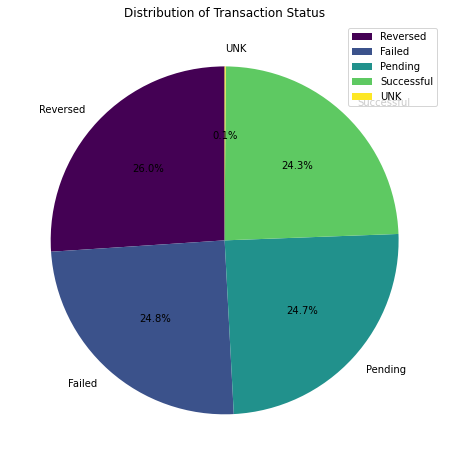

In [27]:
status_counts = df_transaction_issues['Status'].value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 8))
status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='viridis', legend=True)
plt.title('Distribution of Transaction Status')
plt.ylabel('')  # Remove the default y-axis label
plt.show()

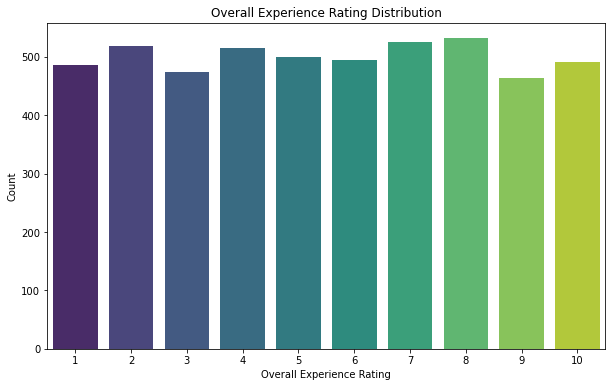

In [28]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='Overall_Experience_Rating', data=df_survey, palette='viridis')
plt.title('Overall Experience Rating Distribution')
plt.xlabel('Overall Experience Rating')
plt.ylabel('Count')
plt.show()

#### Get the time of the day in which the Banking Hall is most active

In [29]:
# Clean the 'AverageTime' column to fix wrong time format
df_transaction_chrurn['AverageTime'] = df_transaction_chrurn['AverageTime'].str.split(' P').str[0]
# Convert 'AverageTime' to a uniform time format
df_transaction_chrurn['AverageTime'] = pd.to_datetime(df_transaction_chrurn['AverageTime'], format='%H:%M:%S').dt.time

# Extract hour from 'AverageTime' for further analysis
df_transaction_chrurn['Hour'] = pd.to_datetime(df_transaction_chrurn['AverageTime'], format='%H:%M:%S', errors='coerce').dt.hour



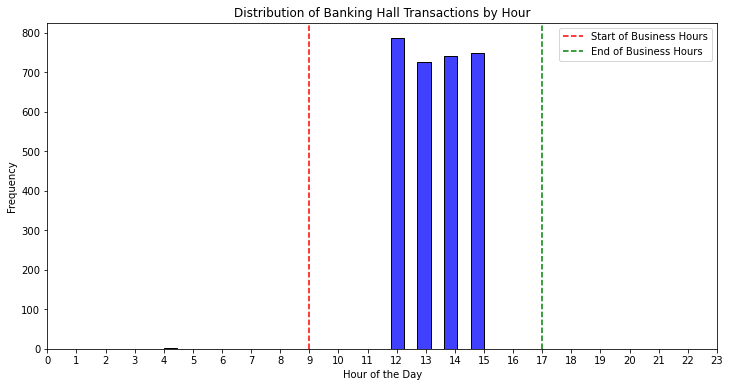

In [30]:
# Plot the distribution of hours
plt.figure(figsize=(12, 6))
sns.histplot(df_transaction_chrurn['Hour'].dropna(), bins=24, kde=False, color='blue')

# Add vertical lines for specific hours (e.g., peak hours)
plt.axvline(x=9, color='red', linestyle='--', label='Start of Business Hours')
plt.axvline(x=17, color='green', linestyle='--', label='End of Business Hours')

# Add labels and title
plt.title('Distribution of Banking Hall Transactions by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Frequency')
plt.xticks(range(0, 24))
plt.legend()
plt.show()


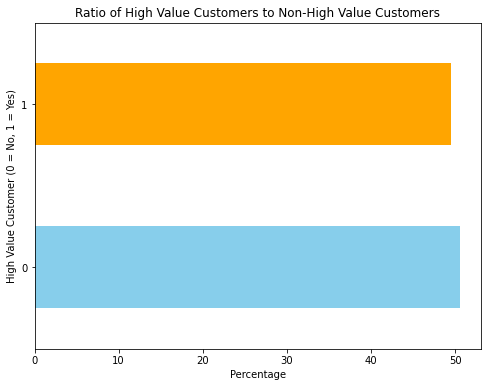

In [31]:
# Calculate the percentage of HighValueCustomer
high_value_percentage = df_transaction_chrurn['HighValueCustomer'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 6))
high_value_percentage.plot(kind='barh', color=['skyblue', 'orange'])
plt.title('Ratio of High Value Customers to Non-High Value Customers')
plt.xlabel('Percentage')
plt.ylabel('High Value Customer (0 = No, 1 = Yes)')
plt.show()

#### Combine the different datasources into one

In [32]:
# Remove duplicates from CRM data based on 'CustomerID' and keep the first occurrence
df_customer_error = df_customer_error.drop_duplicates(subset='CustomerID', keep='first')

In [33]:
latest_experience = df_survey.sort_values(by=['CustomerID', 'Overall_Experience_Rating'], ascending=[True, False]).drop_duplicates(subset='CustomerID')

# Sort transaction_issues by 'Date' to get the latest occurrence of 'Transaction_Type', 'Channel', and 'Status'
latest_transactions = df_transaction_issues.sort_values(by='Date', ascending=False).drop_duplicates(subset='CustomerID')

# Sort transaction_chrurn data by 'LastTransactionDate' to get the latest occurrence of required columns
latest_transaction_data = df_transaction_chrurn.sort_values(by='LastTransactionDate', ascending=False).drop_duplicates(subset='CustomerID')

# Get the aggregate sum of 'TotalTransactionAmount' for each CustomerID
total_transaction_amount = df_transaction_chrurn.groupby('CustomerID')['TotalTransactionAmount'].sum().reset_index()

# Merge all the dataframes
merged_customer_data = df_customer_error.merge(
    latest_experience[['CustomerID', 'Overall_Experience_Rating']], on='CustomerID', how='left'
).merge(
    latest_transactions[['CustomerID', 'Transaction_Type', 'Channel', 'Status']], on='CustomerID', how='left'
).merge(
    latest_transaction_data[['CustomerID', 'DaysSinceLastTransaction', 'DigitalPlatformUsageScore', 'BranchTransactionFrequency', 'AverageTime', 'ComplaintsRaised','HighValueCustomer']], on='CustomerID', how='left'
).merge(
    total_transaction_amount, on='CustomerID', how='left'
)

# Rename the column for clarity
merged_customer_data.rename(columns={'TotalTransactionAmount': 'Sum_TotalTransactionAmount'}, inplace=True)

# Display the resulting DataFrame
print(merged_customer_data.head())

  CustomerID               Full_Name                      Email  \
0   CUST6218             Seth Howard  kennethpierce@hotmail.com   
1   CUST9657            Angel Obrien          nmosley@gmail.com   
2   CUST3929         Tiffany Hartman       kathleen93@reyes.com   
3   CUST1666           Stacy Mendoza  leslie97@ellis-cooper.com   
4   CUST5016  Mr. Charles Williams V         hjones@hotmail.com   

                   Phone                                            Address  \
0     985.802.9653x77096  7139 William Station, South Jenniferfurt, MS 4...   
1       207-943-3879x247           17911 Samantha Road, Annaburgh, TX 29445   
2       001-356-012-0670    3671 Williams Prairie, North Jodifort, MD 86442   
3       021.101.0794x586         76601 Meghan Parks, Jacksonhaven, ME 18301   
4  +1-745-170-1007x26950             27765 Adams Forks, Moorefurt, NY 76173   

  Date_of_Birth  Occupation    Industry Lead_Source Preferred_Contact_Method  \
0     8/16/1991    Engineer     Finance   

In [34]:
# Display the shape of the merged DataFrame
merged_customer_data.shape

(3724, 23)

#### Derive new feature 'Churn' for customers that have not Transacted in over 100 days

In [35]:
# Add a new column 'Churn' based on the condition
merged_customer_data['Churn'] = merged_customer_data['DaysSinceLastTransaction'].apply(lambda x: 1 if x > 100 else 0)

# Display the updated DataFrame
print(merged_customer_data[['CustomerID', 'DaysSinceLastTransaction', 'Churn']].head())


  CustomerID  DaysSinceLastTransaction  Churn
0   CUST6218                     383.0      1
1   CUST9657                     274.0      1
2   CUST3929                      47.0      0
3   CUST1666                     356.0      1
4   CUST5016                      38.0      0


### Machine Learning Model to predict churn

##### Import model dev related libraries 

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

#### Seperate dependent and independent variables

In [37]:
# Select features and target variable
features = ['Overall_Experience_Rating', 'DigitalPlatformUsageScore', 'BranchTransactionFrequency', 
            'ComplaintsRaised', 'HighValueCustomer', 'Sum_TotalTransactionAmount']
target = 'Churn'

# Drop rows with missing values in the selected features
merged_customer_data = merged_customer_data.dropna(subset=features + [target])

#### Encode categorical variables

In [38]:
# Encode categorical variables if necessary
label_encoders = {}
for col in merged_customer_data.select_dtypes(include=['object']).columns:
    if col in features:
        le = LabelEncoder()
        merged_customer_data[col] = le.fit_transform(merged_customer_data[col])
        label_encoders[col] = le

#### Split train and test data

In [39]:
# Split the data into training and testing sets
X = merged_customer_data[features]
y = merged_customer_data[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Train model using Random forest

In [40]:
# Train a Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

#### Predict using trained model

In [41]:
# Make predictions
y_pred = model.predict(X_test)

#### Model evaluation

In [42]:
# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7369127516778523

Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.09      0.14       177
           1       0.77      0.94      0.84       568

    accuracy                           0.74       745
   macro avg       0.54      0.51      0.49       745
weighted avg       0.66      0.74      0.68       745

